## 0. Импорт модулей 

In [1]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from modules.parser import parse_srx_syslog, compute_session_duration, debug_line
from modules.parser import parse_srx_syslog as parse_srx_logs
from modules.features import engineer_features, prepare_features
from modules.export_anomalies import export_top_anomalies
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from modules.models import IsolationForestDetector, DBSCANDetector, AutoencoderDetector, LOFDetector, OneClassSVMDetector
import modules.eda as eda

2026-03-10 07:15:22.874140: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-10 07:15:22.951393: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-10 07:15:24.452966: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Загрузка данных

In [2]:
print('Парсинг начальных логов в DataFrame')
df = parse_srx_logs('data/data_raw/attack_filtered_static.log')

# Удалить столбец hostname, т.к. никакой смысловой нагрузки он не несёт 
df.drop(columns=['hostname'], inplace=True)
print(df.info())

# Удалить запросы к DNS серверам и ICMP траффик, т.к. это сбивает модель
df = df[df['dst_port'] != 53 ]
df = df[df['protocol'] != 'ICMP']

print('Парсинг завершён, результаты сохранены в parsed_df.csv')
df.to_csv("data/prediction_tmp/parsed_df.csv", index=False)

print(f"\nРазмер датасета: {df.shape[0]} записей, {df.shape[1]} колонок")
print(f"Колонки: {list(df.columns)}")

Парсинг начальных логов в DataFrame
Загружено записей:  7771447
Пропущено строк:    20
Event types: {'RT_FLOW_SESSION_CREATE': 3890749, 'RT_FLOW_SESSION_CLOSE': 3880698}
Протоколы:   {'TCP': 7749783, 'UDP': 11977, 'ICMP': 9483, 'GRE': 204}
<class 'pandas.DataFrame'>
RangeIndex: 7771447 entries, 0 to 7771446
Data columns (total 26 columns):
 #   Column         Dtype
---  ------         -----
 0   timestamp      str  
 1   event_type     str  
 2   reason_text    str  
 3   src_ip         str  
 4   src_port       int64
 5   dst_ip         str  
 6   dst_port       int64
 7   application    str  
 8   nat_src_ip     str  
 9   nat_src_port   int64
 10  nat_dst_ip     str  
 11  nat_dst_port   int64
 12  policy         str  
 13  src_zone       str  
 14  dst_zone       str  
 15  protocol_num   int64
 16  src_interface  str  
 17  dst_interface  str  
 18  session_id     str  
 19  pkts_sent      int64
 20  bytes_sent     int64
 21  pkts_rcvd      int64
 22  bytes_rcvd     int64
 23  pro

## 2. Вычисление продолжительности сессии, время между SESSION_CREATE и SESSION_CLOSE

In [3]:
parsed_df = pd.read_csv("data/prediction_tmp/parsed_df.csv")
df_duration = compute_session_duration(df)

# Удалить все записи у которых session duration = 0
df_duration = df_duration[df_duration['duration'] != 0]

print(f"\nРазмер датасета: {df_duration.shape[0]} записей, {df_duration.shape[1]} колонок")
print(f"Колонки: {list(df_duration.columns)}")

print("Информация о датасете")
print(df_duration.info())

# Сохранить DataFrame с вычисленным столбцом duration и содержащий только сессии типа CLOSE
df_duration.to_csv("data/prediction_tmp/processed_session_closed_df.csv", index=False)

# Первые строкт датасета
df_duration.head()

/tmp/ipykernel_803544/727171184.py:1: DtypeWarning: Columns (0: policy) have mixed types. Specify dtype option on import or set low_memory=False.
  parsed_df = pd.read_csv("data/prediction_tmp/parsed_df.csv")


  48283 сессий без CREATE (начались до лог-файла) → duration = median (2.0 сек)
Session duration: 3826513/3874796 сессий имеют пару CREATE+CLOSE (98.8%)

Размер датасета: 3736136 записей, 26 колонок
Колонки: ['timestamp', 'event_type', 'reason_text', 'src_ip', 'src_port', 'dst_ip', 'dst_port', 'application', 'nat_src_ip', 'nat_src_port', 'nat_dst_ip', 'nat_dst_port', 'policy', 'src_zone', 'dst_zone', 'protocol_num', 'src_interface', 'dst_interface', 'session_id', 'pkts_sent', 'bytes_sent', 'pkts_rcvd', 'bytes_rcvd', 'protocol', 'action', 'duration']
Информация о датасете
<class 'pandas.DataFrame'>
Index: 3736136 entries, 0 to 3874795
Data columns (total 26 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      str    
 1   event_type     str    
 2   reason_text    str    
 3   src_ip         str    
 4   src_port       int64  
 5   dst_ip         str    
 6   dst_port       int64  
 7   application    str    
 8   nat_src_ip     str    
 9   nat_src_port

,timestamp,event_type,reason_text,src_ip,src_port,dst_ip,dst_port,application,nat_src_ip,nat_src_port,...,src_interface,dst_interface,session_id,pkts_sent,bytes_sent,pkts_rcvd,bytes_rcvd,protocol,action,duration
0,Mar 4 12:00:06,RT_FLOW_SESSION_CLOSE,session closed idle Timeout:,170.39.218.251,34337,94.139.151.218,8728,None,170.39.218.251,34337,...,internet_static,untrust,1215494462522,0,0,0,0,TCP,close,2.0
1,Mar 4 12:00:06,RT_FLOW_SESSION_CLOSE,session closed idle Timeout:,37.27.10.179,58266,94.139.151.225,22,junos-ssh,37.27.10.179,58266,...,internet_static,untrust,1357230563877,0,0,0,0,TCP,close,2.0
2,Mar 4 12:00:06,RT_FLOW_SESSION_CLOSE,session closed idle Timeout:,198.235.24.234,51602,94.139.151.235,49502,None,198.235.24.234,51602,...,internet_static,untrust,1335734999475,0,0,0,0,TCP,close,2.0
3,Mar 4 12:00:06,RT_FLOW_SESSION_CLOSE,session closed idle Timeout:,116.178.129.204,48398,94.139.151.200,8999,None,116.178.129.204,48398,...,internet_static,untrust,1232668074061,0,0,0,0,TCP,close,2.0
4,Mar 4 12:00:06,RT_FLOW_SESSION_CLOSE,session closed idle Timeout:,85.217.140.29,56263,94.139.151.228,4051,None,85.217.140.29,56263,...,internet_static,untrust,1236954857024,0,0,0,0,TCP,close,2.0


## 3. Feature Engineering

In [4]:
print("\nПрименяем feature engineering...")
df = pd.read_csv("data/prediction_tmp/processed_session_closed_df.csv")
df_features = engineer_features(df)
df_features.to_csv("data/prediction_tmp/feature_eng_done.csv", index=False)
print("Признаки сохранены: feature_eng_done.csv")

print("Информация о датасете")
print(df_features.info())


Применяем feature engineering...


/tmp/ipykernel_803544/669520901.py:2: DtypeWarning: Columns (0: policy) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/prediction_tmp/processed_session_closed_df.csv")


Признаки сохранены: feature_eng_done.csv
Информация о датасете
<class 'pandas.DataFrame'>
RangeIndex: 3736136 entries, 0 to 3736135
Data columns (total 58 columns):
 #   Column                Dtype         
---  ------                -----         
 0   timestamp             datetime64[us]
 1   event_type            str           
 2   reason_text           str           
 3   src_ip                str           
 4   src_port              int64         
 5   dst_ip                str           
 6   dst_port              int64         
 7   application           str           
 8   nat_src_ip            str           
 9   nat_src_port          int64         
 10  nat_dst_ip            str           
 11  nat_dst_port          int64         
 12  policy                str           
 13  src_zone              float64       
 14  dst_zone              float64       
 15  protocol_num          int64         
 16  src_interface         str           
 17  dst_interface         str       

## 4. Визуализация

In [5]:
# Настройки графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

/tmp/ipykernel_803544/3349986326.py:1: DtypeWarning: Columns (0: policy) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/prediction_tmp/feature_eng_done.csv')


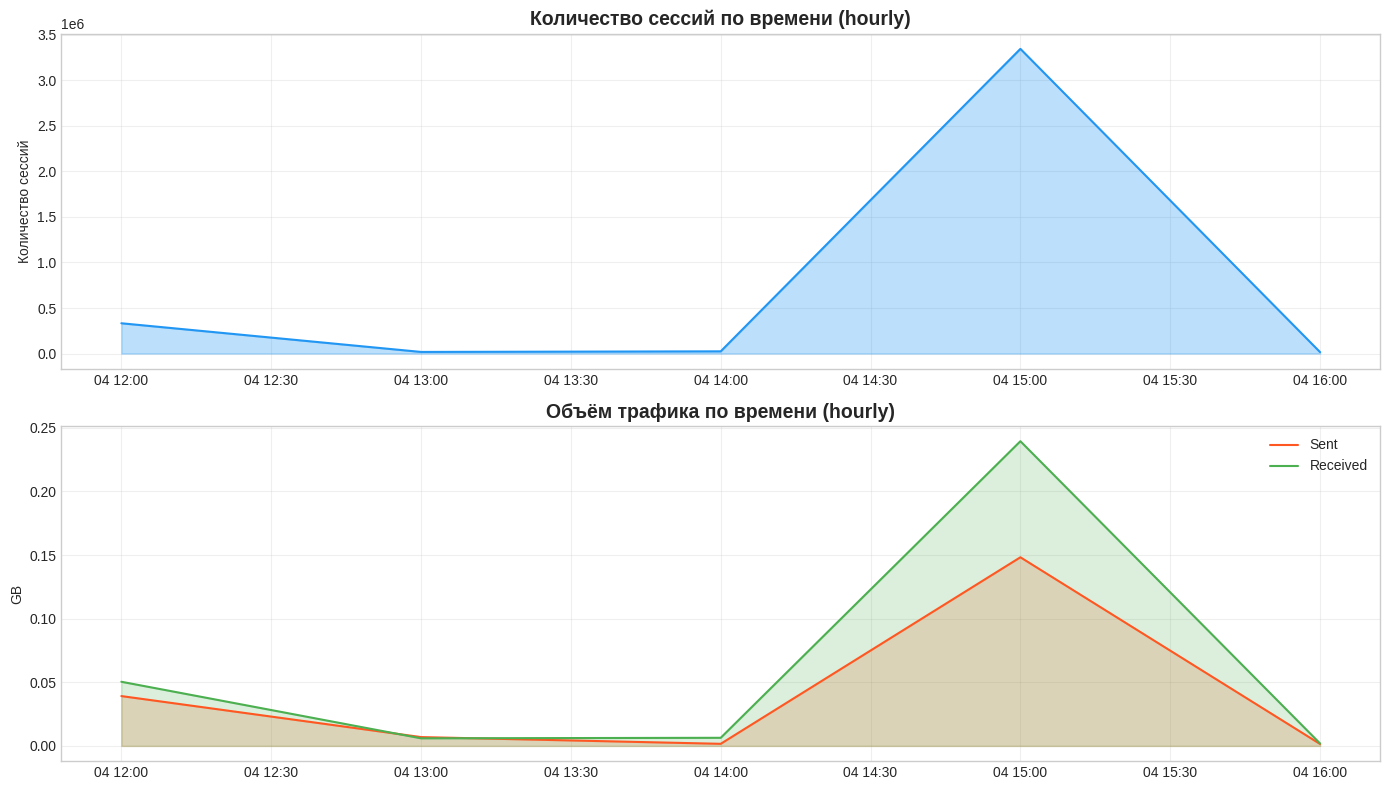

✓ Сохранён: reports/eda/01_traffic_timeline.png


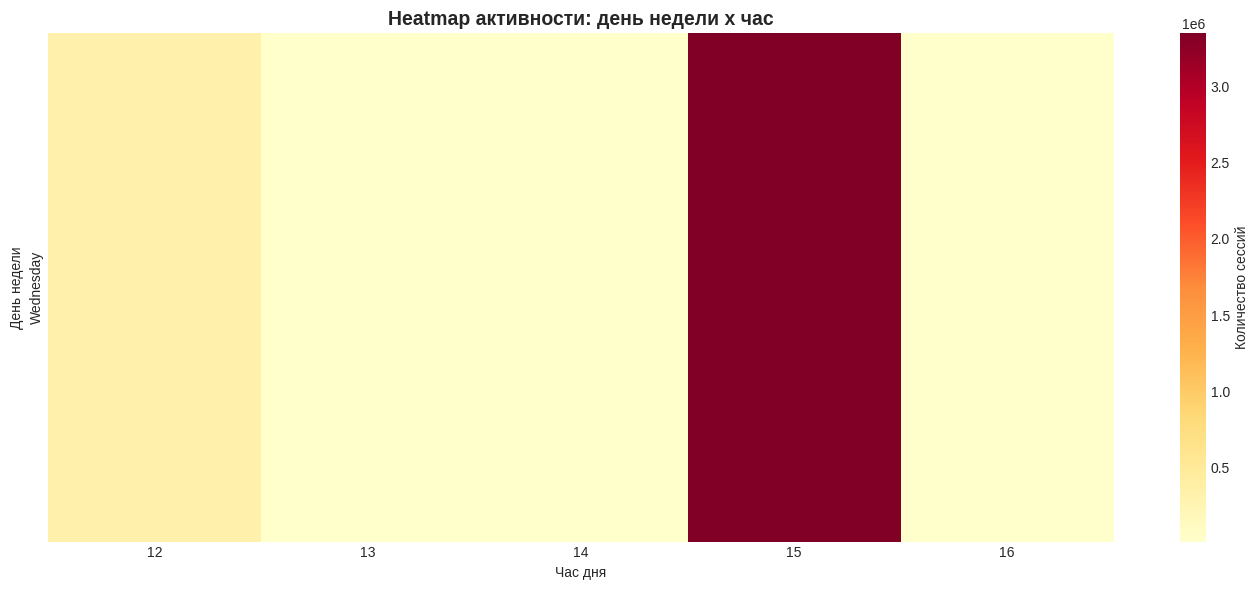

✓ Сохранён: reports/eda/02_activity_heatmap.png


In [6]:
df = pd.read_csv('data/prediction_tmp/feature_eng_done.csv')
eda.plot_traffic_timeline(df)
eda.plot_activity_heatmap(df)

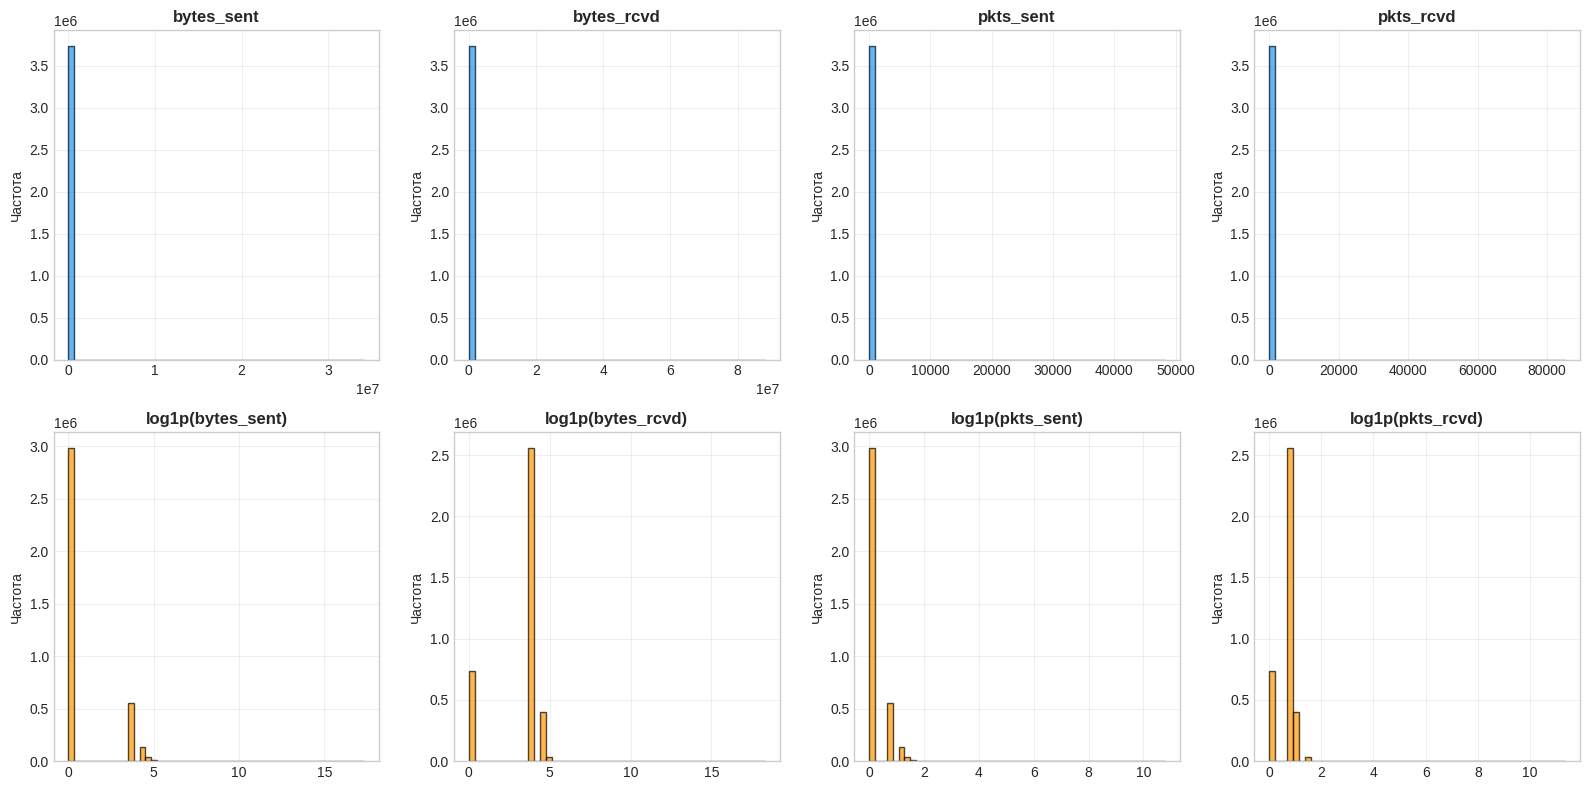

✓ Сохранён: reports/eda/03_feature_distributions.png


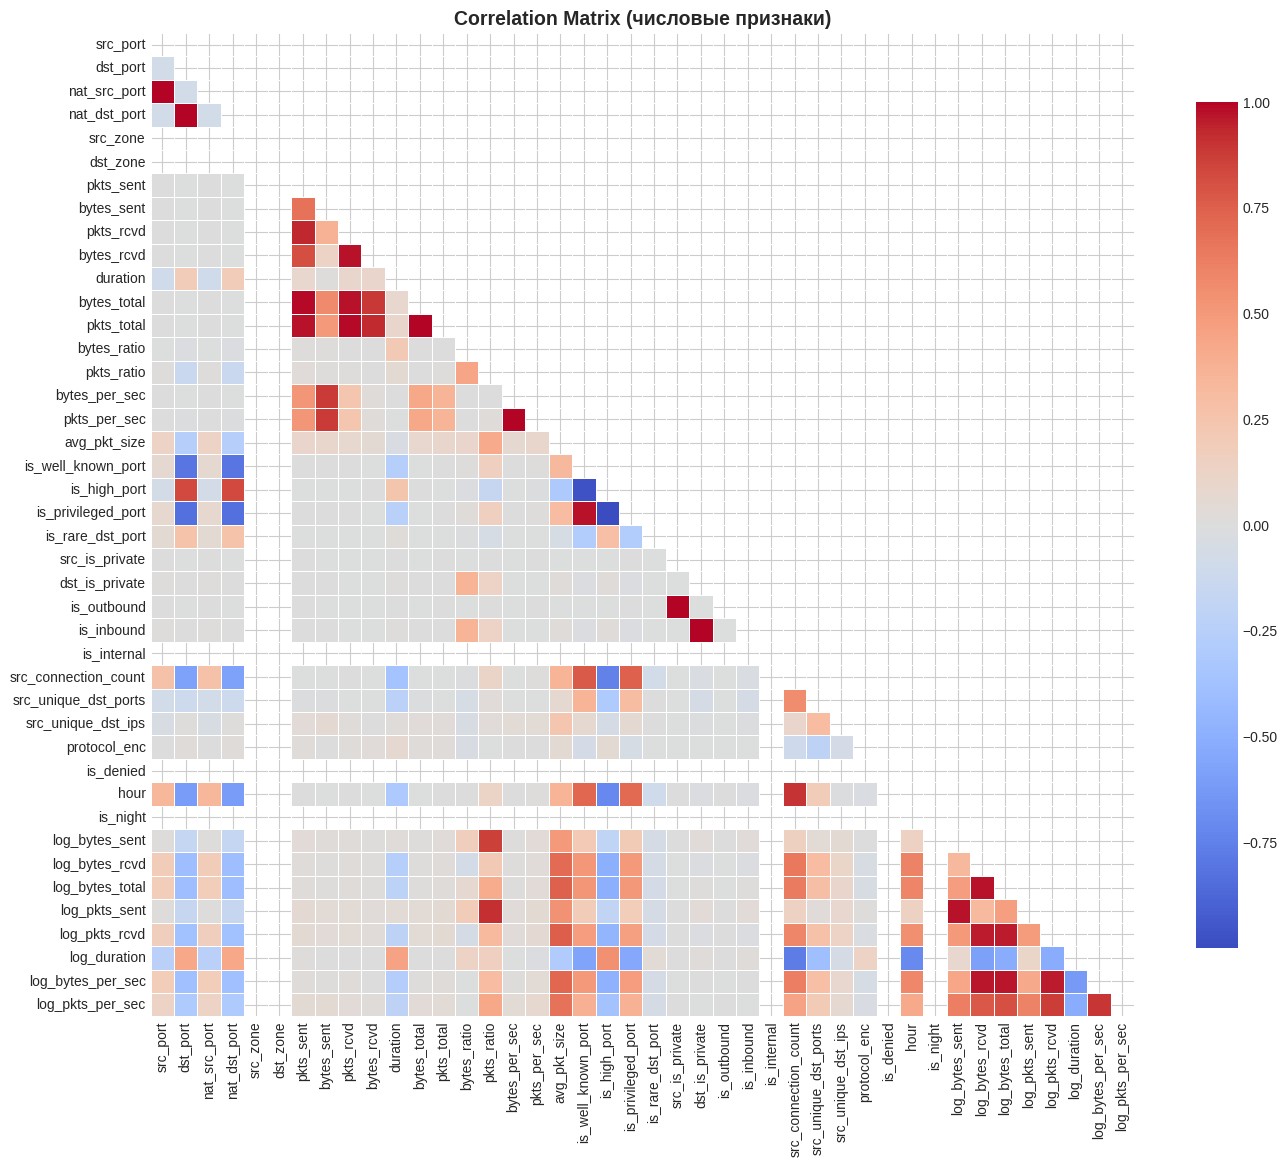

✓ Сохранён: reports/eda/04_correlation_heatmap.png


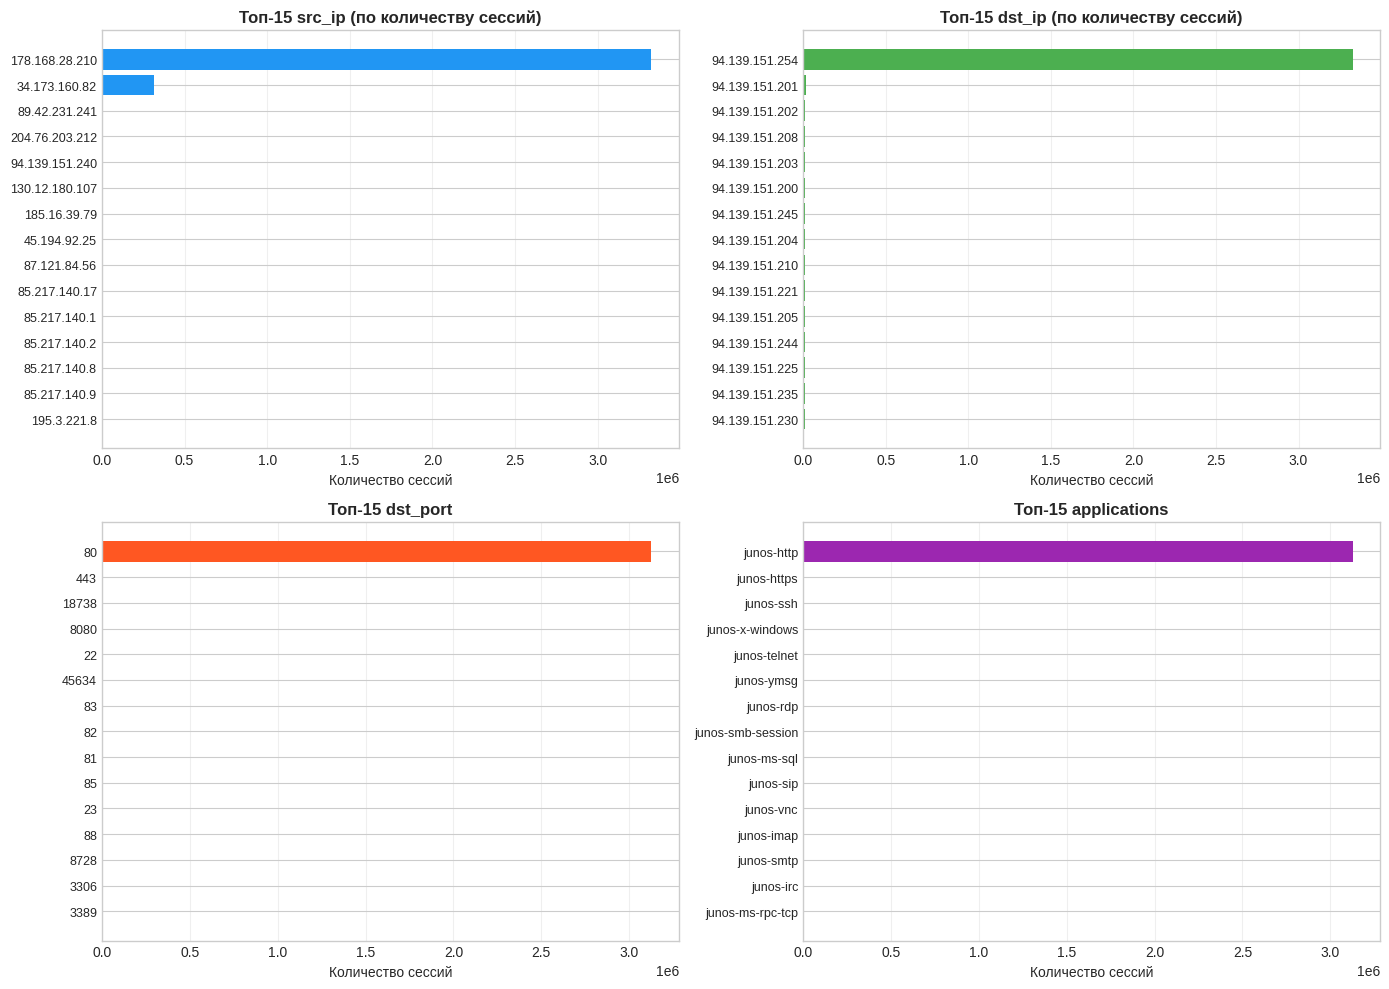

✓ Сохранён: reports/eda/05_top_ips_ports_apps.png


In [7]:
eda.plot_feature_distributions(df)
eda.plot_correlation_heatmap(df)
eda.plot_top_ips_and_ports(df)

## 5. Подготовка матрицы признаков

In [8]:
df_features = pd.read_csv('data/prediction_tmp/feature_eng_done.csv')
print(df_features.shape)
X, scaler, feature_names = prepare_features(df_features, fit=True)

print(f"Матрица X: {X.shape}")

# Сохраняем scaler для inference
with open("data/prediction_tmp/pickle_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Сохраняем данные для будущего обучения моделей
np.save("data/prediction_tmp/X.npy", X)

print('\nСписок финальных признаков используемых для обучения модели:')
for feature in feature_names:
    print(feature)

/tmp/ipykernel_803544/407386624.py:1: DtypeWarning: Columns (0: policy) have mixed types. Specify dtype option on import or set low_memory=False.
  df_features = pd.read_csv('data/prediction_tmp/feature_eng_done.csv')


(3736136, 58)
Признаков для модели: 30
Матрица X: (3736136, 30)

Список финальных признаков используемых для обучения модели:
log_bytes_sent
log_bytes_rcvd
log_bytes_total
log_pkts_sent
log_pkts_rcvd
log_duration
log_bytes_per_sec
log_pkts_per_sec
bytes_ratio
pkts_ratio
avg_pkt_size
dst_port
src_port
is_well_known_port
is_high_port
is_privileged_port
is_rare_dst_port
src_is_private
dst_is_private
is_outbound
is_inbound
is_internal
src_connection_count
src_unique_dst_ports
src_unique_dst_ips
protocol_enc
is_denied
hour
day_of_week
is_night


## 6. Использование модели

### Isolation Forest

In [9]:
# Использование модели IsolationForest для предсказаний

print('Загрузить предобработанные данные')
Y = np.load("data/prediction_tmp/X.npy")

print('Загрузить фаил уже обученной модели')
with open("models/isolation_forest.pkl", "rb") as f:
   isolation_forest_model = pickle.load(f)

y_pred = isolation_forest_model.predict(Y)
y_pred = np.where(y_pred == -1, 1, 0)
print('===================== Результаты предсказаний ======================')
values, counts = np.unique(y_pred, return_counts=True)
print('1 - аномалия, 0 - норма')
print(values)
print(counts)

print('=======================================')
scores = -isolation_forest_model.score_samples(Y)

print("Isolation Forest score is ", scores)
print("min:", scores.min())
print("max:", scores.max())

df_features = pd.read_csv('data/prediction_tmp/feature_eng_done.csv')

# Экспорт от Isolation Forest
export_top_anomalies(
        df_features, y_pred,
        scores,
        "Isolation_Forest", top_n=100,
        output_dir = 'data/prediction_tmp/'
    )

Загрузить предобработанные данные
Загрузить фаил уже обученной модели
===================== Результаты предсказаний ======================
1 - аномалия, 0 - норма
[0 1]
[3732115    4021]
Isolation Forest score is  [0.49836642 0.44205559 0.52443812 ... 0.50745241 0.45837855 0.53260006]
min: 0.4168927444670422
max: 0.7567302793366224


/tmp/ipykernel_803544/785224954.py:25: DtypeWarning: Columns (0: policy) have mixed types. Specify dtype option on import or set low_memory=False.
  df_features = pd.read_csv('data/prediction_tmp/feature_eng_done.csv')


✓ Экспортировано 100 аномалий: data/prediction_tmp/anomalies_isolation_forest_top100.csv
  Для ручной проверки: заполните колонки 'manual_label' и 'notes'


'data/prediction_tmp/anomalies_isolation_forest_top100.csv'

### 6.2 AUTOENCODER (Neural Network)

In [10]:
# Использование модели AutoencoderDetector для предсказаний

print('Загрузить предобработанные данные')
Y = np.load("data/prediction_tmp/X.npy")

print('Загрузить фаил уже обученной модели')
autoencoder_model = AutoencoderDetector()
autoencoder_model.load("models/autoencoder.pkl")

print(type(autoencoder_model))

y_pred = autoencoder_model.predict(Y)
scores = autoencoder_model.score(Y)

print("AutoencoderDetector score is ", scores)
print("min:", scores.min())
print("max:", scores.max())

df_features = pd.read_csv('data/prediction_tmp/feature_eng_done.csv')

# Экспорт от AUTOENCODER
export_top_anomalies(
        df_features, y_pred,
        scores,
        "AutoencoderDetector", top_n=100,
        output_dir = 'data/prediction_tmp/'
    )

Загрузить предобработанные данные
Загрузить фаил уже обученной модели
<class 'modules.models.AutoencoderDetector'>
AutoencoderDetector score is  [2.1309727  2.61253231 4.54666088 ... 5.46141891 2.11351572 2.59623911]
min: 0.054563325238345936
max: 128159.18528069613


/tmp/ipykernel_803544/32455650.py:19: DtypeWarning: Columns (0: policy) have mixed types. Specify dtype option on import or set low_memory=False.
  df_features = pd.read_csv('data/prediction_tmp/feature_eng_done.csv')


✓ Экспортировано 100 аномалий: data/prediction_tmp/anomalies_autoencoderdetector_top100.csv
  Для ручной проверки: заполните колонки 'manual_label' и 'notes'


'data/prediction_tmp/anomalies_autoencoderdetector_top100.csv'

### 6.3 LOFDetector (Neural Network)

In [11]:
# Использование модели LOFDetector для предсказаний

print('Загрузить предобработанные данные')
Y = np.load("data/prediction_tmp/X.npy")

print('Загрузить фаил уже обученной модели')
lof_model = LOFDetector()
lof_model.load("models/lofmodel.pkl")

y_pred = lof_model.predict(Y)
scores = lof_model.score(Y)

print("LOFDetector score is ", scores)
print("min:", scores.min())
print("max:", scores.max())

df_features = pd.read_csv('data/prediction_tmp/feature_eng_done.csv')

# Экспорт от LOFDetector
export_top_anomalies(
        df_features, y_pred,
        scores,
        "LOFDetector", top_n=100,
        output_dir = 'data/prediction_tmp/'
    )

Загрузить предобработанные данные
Загрузить фаил уже обученной модели
LOFDetector score is  [17.505596   26.30068781 63.4227423  ... 45.73052309 18.51723449
 16.98286521]
min: 1.2973543333151707
max: 18618754.62942011


/tmp/ipykernel_803544/1338444691.py:17: DtypeWarning: Columns (0: policy) have mixed types. Specify dtype option on import or set low_memory=False.
  df_features = pd.read_csv('data/prediction_tmp/feature_eng_done.csv')


✓ Экспортировано 100 аномалий: data/prediction_tmp/anomalies_lofdetector_top100.csv
  Для ручной проверки: заполните колонки 'manual_label' и 'notes'


'data/prediction_tmp/anomalies_lofdetector_top100.csv'

### 6.4 OneClassSVMDetector

In [12]:
# Использование модели OneClassSVMDetector для предсказаний

print('Загрузить предобработанные данные')
Y = np.load("data/prediction_tmp/X.npy")

print('Загрузить фаил уже обученной модели')
oneclasssvm_model = OneClassSVMDetector()
oneclasssvm_model.load("models/oneclasssvm_model.pkl")

y_pred = lof_model.predict(Y)
scores = lof_model.score(Y)

print("OneClassSVMDetector score is ", scores)
print("min:", scores.min())
print("max:", scores.max())

df_features = pd.read_csv('data/prediction_tmp/feature_eng_done.csv')

# Экспорт от LOFDetector
export_top_anomalies(
        df_features, y_pred,
        scores,
        "OneClassSVMDetector", top_n=100,
        output_dir = 'data/prediction_tmp/'
    )

Загрузить предобработанные данные
Загрузить фаил уже обученной модели
OneClassSVMDetector score is  [17.505596   26.30068781 63.4227423  ... 45.73052309 18.51723449
 16.98286521]
min: 1.2973543333151707
max: 18618754.62942011


/tmp/ipykernel_803544/3661725115.py:17: DtypeWarning: Columns (0: policy) have mixed types. Specify dtype option on import or set low_memory=False.
  df_features = pd.read_csv('data/prediction_tmp/feature_eng_done.csv')


✓ Экспортировано 100 аномалий: data/prediction_tmp/anomalies_oneclasssvmdetector_top100.csv
  Для ручной проверки: заполните колонки 'manual_label' и 'notes'


'data/prediction_tmp/anomalies_oneclasssvmdetector_top100.csv'